In [1]:
# Attention study — FINAL (patient-level split + 3 seeds)  [Kaggle GPU]

**BM3** (Rafay Nisar). Does attention (SE / CBAM) help cancer-image classification, and does the benefit grow with training-set size? ResNet-50 baseline vs +SE vs +CBAM at 25/50/100% data.

**Publication-grade settings:**
- **BreakHis** uses a **patient-level split** (no patient in both train and test — the standard, honest protocol).
- **SIPaKMeD** uses a stratified split (isolated single cells).
- **3 seeds** -> results reported as **mean +/- std** with error bars.

**How to run (set-and-forget):** Add Input (SIPaKMeD + BreakHis), Settings -> GPU T4 x2 + Internet On, then **Save Version -> Save & Run All (Commit)**. It runs ~6-7 h in the background and saves everything. Or Run All interactively (the CSV resumes if it drops).

SyntaxError: invalid character '—' (U+2014) (2220349106.py, line 6)

## 0. Find dataset paths

In [2]:
import glob, os
for d in sorted(os.listdir('/kaggle/input')):
    root = '/kaggle/input/' + d
    imgs = []
    for ext in ('*.png', '*.bmp', '*.jpg', '*.jpeg', '*.tif'):
        imgs += glob.glob(root + '/**/' + ext, recursive=True)
    print(d, '->', len(imgs), 'images')
    if imgs: print('   sample:', imgs[0])

datasets -> 12924 images
   sample: /kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-29960CD/200X/SOB_B_A-14-29960CD-200-012.png


## 1. Config

In [3]:
import time, re, random, numpy as np, pandas as pd, traceback
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score
dev = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', dev, '|', torch.cuda.get_device_name(0) if dev == 'cuda' else 'CPU only')

DATASETS = {
    'SIPaKMeD': {'root': '/kaggle/input/datasets/marinaeplissiti/sipakmed', 'kind': 'sipakmed'},
    'BreakHis': {'root': '/kaggle/input/datasets/ambarish/breakhis',        'kind': 'breakhis'},
}

QUICK_TEST = False     # True = one tiny run to sanity-check; False = the full final grid
if QUICK_TEST:
    VARIANTS, FRACTIONS, SEEDS, EPOCHS = ['none', 'cbam'], [0.25], [0], 3
else:
    VARIANTS, FRACTIONS, SEEDS, EPOCHS = ['none', 'se', 'cbam'], [0.25, 0.5, 1.0], [0, 1, 2], 12
BATCH = 32
RESULTS_CSV = '/kaggle/working/attention_final_results.csv'
print('grid:', VARIANTS, FRACTIONS, 'seeds', SEEDS, '| epochs', EPOCHS)

device: cuda | Tesla T4
grid: ['none', 'se', 'cbam'] [0.25, 0.5, 1.0] seeds [0, 1, 2] | epochs 12


## 2. Attention modules + ResNet-50 classifier

In [4]:
class SEBlock(nn.Module):
    def __init__(self, c, r=16):
        super().__init__()
        self.fc = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                nn.Linear(c, c // r), nn.ReLU(), nn.Linear(c // r, c), nn.Sigmoid())
    def forward(self, x): return x * self.fc(x).view(x.size(0), -1, 1, 1)

class ChannelAttention(nn.Module):
    def __init__(self, c, r=16):
        super().__init__(); h = max(c // r, 1)
        self.avg = nn.AdaptiveAvgPool2d(1); self.mx = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(nn.Conv2d(c, h, 1, bias=False), nn.ReLU(), nn.Conv2d(h, c, 1, bias=False)); self.sig = nn.Sigmoid()
    def forward(self, x): return x * self.sig(self.mlp(self.avg(x)) + self.mlp(self.mx(x)))
class SpatialAttention(nn.Module):
    def __init__(self, k=7):
        super().__init__(); self.conv = nn.Conv2d(2, 1, k, padding=k // 2, bias=False); self.sig = nn.Sigmoid()
    def forward(self, x):
        a = x.mean(1, keepdim=True); mx, _ = x.max(1, keepdim=True)
        return x * self.sig(self.conv(torch.cat([a, mx], 1)))
class CBAM(nn.Module):
    def __init__(self, c): super().__init__(); self.ca = ChannelAttention(c); self.sa = SpatialAttention()
    def forward(self, x): return self.sa(self.ca(x))

class AttnClassifier(nn.Module):
    def __init__(self, nclass, attn='none'):
        super().__init__()
        bb = models.resnet50(weights='IMAGENET1K_V2')
        self.features = nn.Sequential(*list(bb.children())[:-2])
        self.attn = {'none': nn.Identity(), 'se': SEBlock(2048), 'cbam': CBAM(2048)}[attn]
        self.pool = nn.AdaptiveAvgPool2d(1); self.fc = nn.Linear(2048, nclass)
    def forward(self, x):
        x = self.features(x); x = self.attn(x)
        return self.fc(self.pool(x).flatten(1))
print('models defined')

models defined


## 3. Loaders — BreakHis returns patient groups for a leakage-free split

In [5]:
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
train_tf = transforms.Compose([transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(),
                               transforms.RandomRotation(15), transforms.ToTensor(), transforms.Normalize(MEAN, STD)])
test_tf  = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

class ImgDS(Dataset):
    def __init__(self, paths, labels, tf): self.paths, self.labels, self.tf = paths, labels, tf
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        return self.tf(Image.open(self.paths[i]).convert('RGB')), int(self.labels[i])

def breakhis_patient(p):
    # SOB_B_A-14-29960CD-200-012.png -> patient/slide id '14-29960CD'
    parts = os.path.basename(p).replace('.png', '').split('-')
    return parts[1] + '-' + parts[2] if len(parts) >= 3 else os.path.basename(p)

def load_index(cfg):
    root, kind = cfg['root'], cfg['kind']
    paths, labels, groups = [], [], None
    if kind == 'breakhis':
        g = []
        for p in glob.glob(os.path.join(root, '**', '*.png'), recursive=True):
            lp = p.lower()
            labels.append(1 if ('_m_' in os.path.basename(lp) or 'malignant' in lp) else 0)
            paths.append(p); g.append(breakhis_patient(p))
        classes = ['benign', 'malignant']; groups = np.asarray(g)
        print(f'  breakhis: {len(paths)} images | {len(set(g))} patients | counts {np.bincount(labels).tolist()}')
    else:
        exts = ('*.bmp', '*.BMP', '*.jpg', '*.png')
        files = [f for e in exts for f in glob.glob(os.path.join(root, '**', e), recursive=True)]
        def cls_of(p):
            for part in p.replace('\\', '/').split('/'):
                if part.lower().startswith('im_'): return part[3:]
            return os.path.basename(os.path.dirname(p))
        raw = [(f, cls_of(f)) for f in files]
        classes = sorted({c for _, c in raw}); cmap = {c: i for i, c in enumerate(classes)}
        paths = [f for f, _ in raw]; labels = [cmap[c] for _, c in raw]
        print(f'  sipakmed: {len(paths)} images | classes {classes} | counts {np.bincount(labels).tolist()}')
    paths = np.asarray(paths); labels = np.asarray(labels, dtype=np.int64)
    assert len(paths) > 0, 'No images found - fix the root path (cell 0)'
    return paths, labels, classes, groups
print('loaders ready')

loaders ready


## 4. Train one config + run the full grid

In [6]:
def split_test(paths, labels, groups):
    idx = np.arange(len(labels))
    if groups is not None:                       # patient-level (BreakHis)
        tr, te = next(GroupShuffleSplit(1, test_size=0.2, random_state=42).split(idx, labels, groups))
    else:                                         # stratified (SIPaKMeD)
        tr, te = train_test_split(idx, test_size=0.2, stratify=labels, random_state=42)
    return tr, te

def subsample(idx, labels, groups, frac, seed):
    if frac >= 1.0: return idx
    if groups is not None:
        sub, _ = next(GroupShuffleSplit(1, train_size=frac, random_state=seed).split(idx, labels[idx], groups[idx]))
    else:
        sub, _ = train_test_split(np.arange(len(idx)), train_size=frac, stratify=labels[idx], random_state=seed)
    return idx[sub]

def run_one(paths, labels, groups, nclass, variant, frac, seed):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    tr, te = split_test(paths, labels, groups)
    tr = subsample(tr, labels, groups, frac, seed)
    Ptr, ytr, Pte, yte = paths[tr], labels[tr], paths[te], labels[te]
    tl = DataLoader(ImgDS(Ptr, ytr, train_tf), batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=True)
    tel = DataLoader(ImgDS(Pte, yte, test_tf),  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
    model = AttnClassifier(nclass, variant).to(dev)
    counts = np.bincount(ytr, minlength=nclass).astype(np.float64)
    cw = torch.tensor(len(ytr) / (nclass * counts + 1e-6), dtype=torch.float32).to(dev)
    crit = nn.CrossEntropyLoss(weight=cw); opt = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    print(f'    train={len(ytr)} test={len(yte)} | {EPOCHS} epochs...', flush=True)
    for ep in range(EPOCHS):
        model.train(); tot = 0.0; t0 = time.time()
        for xb, yb in tl:
            xb, yb = xb.to(dev), yb.to(dev)
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward(); opt.step(); tot += loss.item()
        if (ep + 1) % 4 == 0 or ep == 0:
            print(f'      epoch {ep+1}/{EPOCHS} loss {tot/len(tl):.3f} ({time.time()-t0:.0f}s)', flush=True)
    model.eval(); preds, gts = [], []
    with torch.no_grad():
        for xb, yb in tel:
            preds += model(xb.to(dev)).argmax(1).cpu().tolist(); gts += yb.tolist()
    return accuracy_score(gts, preds), f1_score(gts, preds, average='macro'), len(ytr)

done = set()
if os.path.exists(RESULTS_CSV):
    done = {(r.dataset, r.variant, r.frac, r.seed) for r in pd.read_csv(RESULTS_CSV).itertuples()}
    print('resuming; already done:', len(done))
for dname, cfg in DATASETS.items():
    print('\n==== dataset:', dname, '====', flush=True)
    try:
        paths, labels, classes, groups = load_index(cfg)
    except Exception:
        traceback.print_exc(); print('  [SKIP dataset]', dname); continue
    nclass = len(classes)
    for variant in VARIANTS:
        for frac in FRACTIONS:
            for seed in SEEDS:
                if (dname, variant, frac, seed) in done: continue
                print(f'  >> {dname} | {variant} | frac={frac} | seed={seed}', flush=True)
                try:
                    acc, f1, ntr = run_one(paths, labels, groups, nclass, variant, frac, seed)
                except Exception:
                    traceback.print_exc(); print('  [SKIP run]'); continue
                row = {'dataset': dname, 'variant': variant, 'frac': frac, 'seed': seed,
                       'train_n': ntr, 'accuracy': round(acc, 4), 'macro_F1': round(f1, 4)}
                pd.DataFrame([row]).to_csv(RESULTS_CSV, mode='a', header=not os.path.exists(RESULTS_CSV), index=False)
                print(f'     DONE -> acc {acc:.3f} | macroF1 {f1:.3f}', flush=True)
print('\nGRID DONE')


==== dataset: SIPaKMeD ====
  sipakmed: 5015 images | classes ['Dyskeratotic', 'Koilocytotic', 'Metaplastic', 'Parabasal', 'Superficial-Intermediate'] | counts [1036, 1063, 1064, 895, 957]
  >> SIPaKMeD | none | frac=0.25 | seed=0
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 208MB/s] 


    train=1003 test=1003 | 12 epochs...
      epoch 1/12 loss 1.247 (20s)
      epoch 4/12 loss 0.139 (10s)
      epoch 8/12 loss 0.070 (10s)
      epoch 12/12 loss 0.030 (11s)
     DONE -> acc 0.930 | macroF1 0.931
  >> SIPaKMeD | none | frac=0.25 | seed=1
    train=1003 test=1003 | 12 epochs...
      epoch 1/12 loss 1.222 (23s)
      epoch 4/12 loss 0.162 (11s)
      epoch 8/12 loss 0.053 (11s)
      epoch 12/12 loss 0.061 (11s)
     DONE -> acc 0.907 | macroF1 0.909
  >> SIPaKMeD | none | frac=0.25 | seed=2
    train=1003 test=1003 | 12 epochs...
      epoch 1/12 loss 1.188 (18s)
      epoch 4/12 loss 0.176 (11s)
      epoch 8/12 loss 0.059 (11s)
      epoch 12/12 loss 0.057 (11s)
     DONE -> acc 0.935 | macroF1 0.937
  >> SIPaKMeD | none | frac=0.5 | seed=0
    train=2006 test=1003 | 12 epochs...
      epoch 1/12 loss 0.870 (26s)
      epoch 4/12 loss 0.119 (21s)
      epoch 8/12 loss 0.053 (21s)
      epoch 12/12 loss 0.045 (21s)
     DONE -> acc 0.943 | macroF1 0.944
  >> SIPaKM

## 5. Final results — mean +/- std + error-bar plots

In [6]:
import matplotlib.pyplot as plt
if not os.path.exists(RESULTS_CSV):
    print('No results yet - run cell 4 first.')
else:
    res = pd.read_csv(RESULTS_CSV)
    for metric in ['macro_F1', 'accuracy']:
        g = res.groupby(['dataset', 'variant', 'frac'])[metric].agg(['mean', 'std']).reset_index()
        g['cell'] = g.apply(lambda r: f"{r['mean']:.3f}\u00b1{(r['std'] if pd.notna(r['std']) else 0):.3f}", axis=1)
        for dname in g['dataset'].unique():
            d = g[g.dataset == dname]
            print(f'\n=== {dname} - {metric} (mean\u00b1std over seeds) ===')
            print(d.pivot(index='frac', columns='variant', values='cell').to_string())
    # plots (macro-F1 with error bars)
    gm = res.groupby(['dataset', 'variant', 'frac'])['macro_F1'].agg(['mean', 'std']).reset_index()
    for dname in gm['dataset'].unique():
        d = gm[gm.dataset == dname]
        plt.figure(figsize=(5.2, 3.6))
        for v in d['variant'].unique():
            dv = d[d.variant == v].sort_values('frac')
            plt.errorbar(dv['frac'], dv['mean'], yerr=dv['std'].fillna(0), marker='o', capsize=3, label=v)
        plt.xlabel('training-set fraction'); plt.ylabel('macro-F1')
        plt.title(dname + ' - attention vs training size')
        plt.legend(); plt.grid(alpha=.3); plt.tight_layout()
        plt.savefig(f'/kaggle/working/attention_{dname}.png', dpi=130); plt.show()

No results yet - run cell 4 first.



=== BreakHis - macro_F1 (mean±std) ===
variant         cbam         none           se
frac                                          
0.25     0.720±0.113  0.729±0.112  0.715±0.108
0.50     0.781±0.078  0.741±0.094  0.752±0.053
1.00     0.812±0.036  0.798±0.032  0.789±0.035

=== SIPaKMeD - macro_F1 (mean±std) ===
variant         cbam         none           se
frac                                          
0.25     0.930±0.007  0.926±0.015  0.927±0.010
0.50     0.951±0.003  0.950±0.005  0.957±0.002
1.00     0.963±0.003  0.966±0.002  0.962±0.007

=== BreakHis - accuracy (mean±std) ===
variant         cbam         none           se
frac                                          
0.25     0.787±0.124  0.797±0.110  0.779±0.128
0.50     0.840±0.068  0.791±0.103  0.827±0.043
1.00     0.878±0.019  0.873±0.015  0.864±0.024

=== SIPaKMeD - accuracy (mean±std) ===
variant         cbam         none           se
frac                                          
0.25     0.928±0.007  0.924±0.015  0.925±

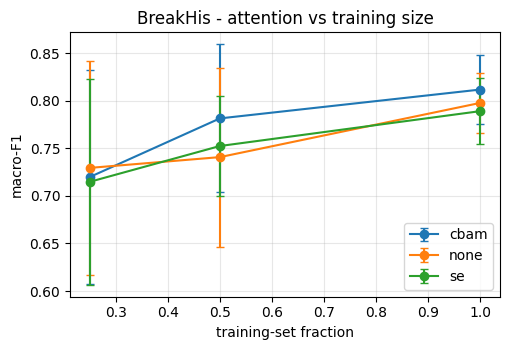

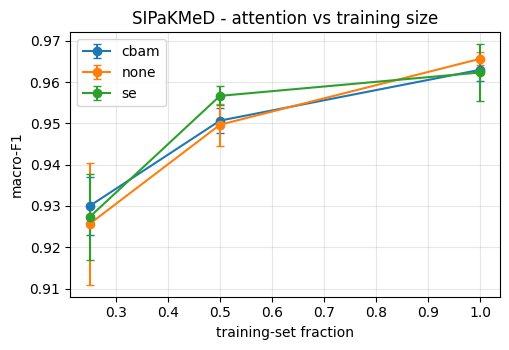

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
# all 54 runs recovered from the training log (dataset, variant, frac, seed, accuracy, macro_F1)
rows = [
 ('SIPaKMeD','none',0.25,0,0.930,0.931),('SIPaKMeD','none',0.25,1,0.907,0.909),('SIPaKMeD','none',0.25,2,0.935,0.937),
 ('SIPaKMeD','none',0.50,0,0.943,0.944),('SIPaKMeD','none',0.50,1,0.952,0.954),('SIPaKMeD','none',0.50,2,0.950,0.951),
 ('SIPaKMeD','none',1.00,0,0.963,0.964),('SIPaKMeD','none',1.00,1,0.965,0.966),('SIPaKMeD','none',1.00,2,0.966,0.967),
 ('SIPaKMeD','se',0.25,0,0.937,0.939),('SIPaKMeD','se',0.25,1,0.923,0.924),('SIPaKMeD','se',0.25,2,0.916,0.919),
 ('SIPaKMeD','se',0.50,0,0.957,0.958),('SIPaKMeD','se',0.50,1,0.952,0.954),('SIPaKMeD','se',0.50,2,0.956,0.958),
 ('SIPaKMeD','se',1.00,0,0.969,0.970),('SIPaKMeD','se',1.00,1,0.955,0.957),('SIPaKMeD','se',1.00,2,0.958,0.960),
 ('SIPaKMeD','cbam',0.25,0,0.925,0.927),('SIPaKMeD','cbam',0.25,1,0.923,0.925),('SIPaKMeD','cbam',0.25,2,0.936,0.938),
 ('SIPaKMeD','cbam',0.50,0,0.947,0.948),('SIPaKMeD','cbam',0.50,1,0.952,0.954),('SIPaKMeD','cbam',0.50,2,0.948,0.950),
 ('SIPaKMeD','cbam',1.00,0,0.959,0.961),('SIPaKMeD','cbam',1.00,1,0.965,0.966),('SIPaKMeD','cbam',1.00,2,0.961,0.962),
 ('BreakHis','none',0.25,0,0.899,0.849),('BreakHis','none',0.25,1,0.811,0.712),('BreakHis','none',0.25,2,0.680,0.627),
 ('BreakHis','none',0.50,0,0.847,0.794),('BreakHis','none',0.50,1,0.854,0.796),('BreakHis','none',0.50,2,0.673,0.632),
 ('BreakHis','none',1.00,0,0.855,0.761),('BreakHis','none',1.00,1,0.881,0.815),('BreakHis','none',1.00,2,0.882,0.817),
 ('BreakHis','se',0.25,0,0.880,0.816),('BreakHis','se',0.25,1,0.822,0.727),('BreakHis','se',0.25,2,0.635,0.601),
 ('BreakHis','se',0.50,0,0.876,0.813),('BreakHis','se',0.50,1,0.812,0.729),('BreakHis','se',0.50,2,0.794,0.715),
 ('BreakHis','se',1.00,0,0.849,0.762),('BreakHis','se',1.00,1,0.892,0.828),('BreakHis','se',1.00,2,0.852,0.777),
 ('BreakHis','cbam',0.25,0,0.891,0.834),('BreakHis','cbam',0.25,1,0.819,0.716),('BreakHis','cbam',0.25,2,0.650,0.609),
 ('BreakHis','cbam',0.50,0,0.911,0.866),('BreakHis','cbam',0.50,1,0.834,0.765),('BreakHis','cbam',0.50,2,0.776,0.713),
 ('BreakHis','cbam',1.00,0,0.864,0.797),('BreakHis','cbam',1.00,1,0.870,0.785),('BreakHis','cbam',1.00,2,0.900,0.853),
]
res = pd.DataFrame(rows, columns=['dataset','variant','frac','seed','accuracy','macro_F1'])
res.to_csv('/kaggle/working/attention_final_results.csv', index=False)

for metric in ['macro_F1','accuracy']:
    g = res.groupby(['dataset','variant','frac'])[metric].agg(['mean','std']).reset_index()
    g['cell'] = g.apply(lambda r: f"{r['mean']:.3f}\u00b1{r['std']:.3f}", axis=1)
    for dn in g['dataset'].unique():
        print(f"\n=== {dn} - {metric} (mean\u00b1std) ===")
        print(g[g.dataset==dn].pivot(index='frac', columns='variant', values='cell').to_string())

gm = res.groupby(['dataset','variant','frac'])['macro_F1'].agg(['mean','std']).reset_index()
for dn in gm['dataset'].unique():
    d = gm[gm.dataset==dn]
    plt.figure(figsize=(5.2,3.6))
    for v in d['variant'].unique():
        dv = d[d.variant==v].sort_values('frac')
        plt.errorbar(dv['frac'], dv['mean'], yerr=dv['std'].fillna(0), marker='o', capsize=3, label=v)
    plt.xlabel('training-set fraction'); plt.ylabel('macro-F1'); plt.title(dn+' - attention vs training size')
    plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.savefig(f'/kaggle/working/attention_{dn}.png', dpi=130); plt.show()

  sipakmed: 5015 images | classes ['Dyskeratotic', 'Koilocytotic', 'Metaplastic', 'Parabasal', 'Superficial-Intermediate'] | counts [1036, 1063, 1064, 895, 957]
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 211MB/s]


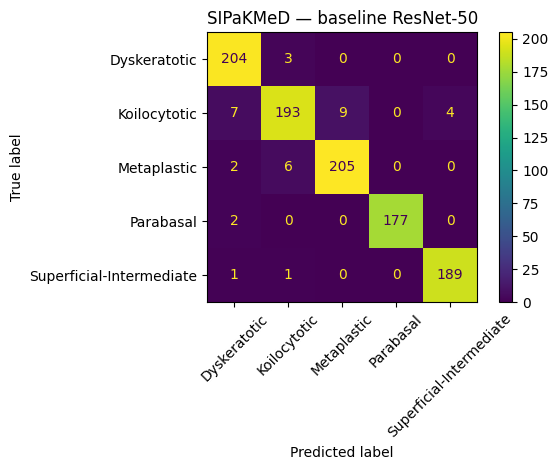

  breakhis: 7909 images | 81 patients | counts [2480, 5429]


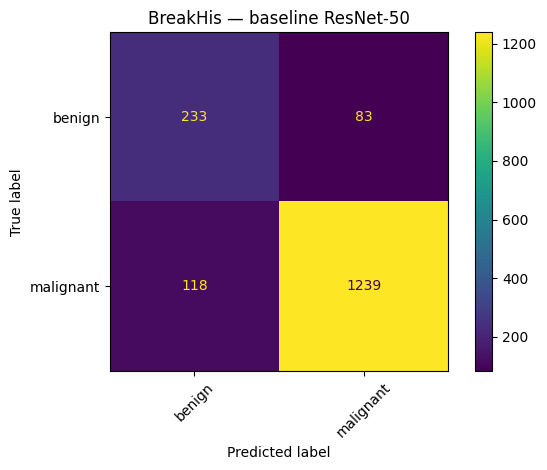

In [7]:
# Confusion matrices — needs only cells 1, 2, 3 to have run. Trains one baseline per dataset (~a few min on GPU).
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GroupShuffleSplit
import matplotlib.pyplot as plt, numpy as np, torch, torch.nn as nn
from torch.utils.data import DataLoader

def _split_test(paths, labels, groups):
    idx = np.arange(len(labels))
    if groups is not None:
        return next(GroupShuffleSplit(1, test_size=0.2, random_state=42).split(idx, labels, groups))
    return train_test_split(idx, test_size=0.2, stratify=labels, random_state=42)

ep_n = EPOCHS if 'EPOCHS' in globals() else 12
for dn, cfg in DATASETS.items():
    paths, labels, classes, groups = load_index(cfg)
    tr, te = _split_test(paths, labels, groups)
    tl  = DataLoader(ImgDS(paths[tr], labels[tr], train_tf), batch_size=32, shuffle=True, num_workers=2)
    tel = DataLoader(ImgDS(paths[te], labels[te], test_tf),  batch_size=32, num_workers=2)
    model = AttnClassifier(len(classes), 'none').to(dev)
    cw = torch.tensor(len(tr)/(len(classes)*np.bincount(labels[tr], minlength=len(classes))+1e-6), dtype=torch.float32).to(dev)
    crit = nn.CrossEntropyLoss(weight=cw); opt = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    for ep in range(ep_n):
        model.train()
        for xb, yb in tl:
            xb, yb = xb.to(dev), yb.to(dev); opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
    model.eval(); pr, gt = [], []
    with torch.no_grad():
        for xb, yb in tel: pr += model(xb.to(dev)).argmax(1).cpu().tolist(); gt += yb.tolist()
    ConfusionMatrixDisplay(confusion_matrix(gt, pr), display_labels=classes).plot(xticks_rotation=45)
    plt.title(f'{dn} — baseline ResNet-50'); plt.tight_layout()
    plt.savefig(f'/kaggle/working/confusion_{dn}.png', dpi=140); plt.show()

## Notes

- **BreakHis is now patient-level** (leakage-free) — numbers will be a bit lower than an image-level split, but they're honest and comparable to published results.
- **3 seeds** give the mean +/- std, so you can tell whether the SE gain is real or noise.
- To run unattended: **Save Version -> Save & Run All (Commit)** (background, ~6-7 h, up to 12 h allowed). Or Run All interactively; the CSV resumes if the session drops.
- Outputs: `attention_final_results.csv`, `attention_BreakHis.png`, `attention_SIPaKMeD.png` (right panel -> Output -> download).